In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
import geopandas as gpd
import numpy as np


## Loading Dataset

In [4]:
df = pd.read_csv("L005169-082426.csv", dtype={"IrwinID": "string"})
df.head()

,Agency,ID_Incident,StartDate,Contained,Controlled,County,FireName,Lat,Long,acres,CauseGeneral,CauseSpecific,CauseSpecificDetail,Department,BadLocation,IrwinID,Shape
0,FD,AEA0A967-E4C9-45C3-BD5F-0000D3C0A9DD,7/17/11 0:00,NaN,NaN,Wichita,Rekindle Krohn Rd,34.091480,-98.898642,0.0,Other causes,Other (remarks required),Unknown (remarks required),Electra VFD,0,<NA>,0xE6100000010CF833BC5983B958C0CD1C37A1B50B4140
1,FD,5E7D8AA7-872F-4C28-849C-0001031ACCD5,4/8/20 12:59,4/8/20 13:16,4/8/20 13:52,Aransas,190,28.057600,-97.104200,0.1,Debris and open burning,Hand pile/slash,Unknown (remarks required),Rockport VFD,0,<NA>,0xE6100000010C910F7A36AB4658C0E63FA4DFBE0E3C40
2,FD,A9DBA206-FB1E-4061-9500-0001FC0A547D,4/25/09 0:00,NaN,NaN,Bee,Grass Fire,28.413202,-97.723735,0.5,Smoking,Cigar/cigarette/pipe,Unknown (remarks required),Beeville Vol. Fire Dept.,0,<NA>,0xE6100000010C000B70AC516E58C07CD43EA1C7693C40
3,FD,E47D6494-9964-4F0A-B4F8-0002615830C7,1/29/08 0:00,NaN,NaN,Bell,7000 Stillman Valley,30.934168,-97.716991,20.0,Debris and open burning,Hand pile/slash,Unknown (remarks required),Florence VFD,0,<NA>,0xE6100000010C5002F62CE36D58C0344205A825EF3E40
4,FD,7CD8FF55-5E90-450B-8687-0002A206891B,6/17/08 0:00,NaN,NaN,Mills,Stone Creek #3,31.557167,-98.665667,1.0,Other causes,Other (remarks required),Unknown (remarks required),Mullin Volunteer Fire Department,0,<NA>,0xE6100000010C874215489AAA58C01E1F6779A28E3F40


## Missing Values

In [18]:
# How complete is each column?
quality = pd.DataFrame({
    "non_missing": df.notna().sum(),
    "missing": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "unique_values": df.nunique(dropna=True)
}).sort_values("missing_pct", ascending=False)

quality

,non_missing,missing,missing_pct,unique_values
IrwinID,11056,274802,96.13,10997
Contained,97945,187913,65.74,94034
Controlled,101968,183890,64.33,95247
CauseSpecificDetail,228386,57472,20.11,54
FireName,285362,496,0.17,186733
Lat,285613,245,0.09,212636
Long,285613,245,0.09,214032
CauseSpecific,285751,107,0.04,68
CauseGeneral,285808,50,0.02,13
Agency,285858,0,0.00,2


## Future Data Quality Issues

In [19]:
checks = pd.Series({
    "Negative acres": (df["acres"] < 0).sum(),
    "Zero acres": (df["acres"] == 0).sum(),
    "Missing latitude or longitude": df[["Lat", "Long"]].isna().any(axis=1).sum(),
    "Coordinates outside rough Texas bounds": (
        ~df["Lat"].between(25, 37) | ~df["Long"].between(-107, -93)
    ).sum(),
    "Flagged BadLocation": (df["BadLocation"] == 1).sum(),
    "Missing CauseGeneral": df["CauseGeneral"].isna().sum()
})

checks

Negative acres                                1
Zero acres                                13543
Missing latitude or longitude               245
Coordinates outside rough Texas bounds      328
Flagged BadLocation                        3104
Missing CauseGeneral                         50
dtype: int64

In [29]:
print("Negative:", (df["acres"] < 0).sum())
print("Zero:", (df["acres"] == 0).sum())
print("Positive:", (df["acres"] > 0).sum())

df["acres"].describe(percentiles=[.5, .75, .90, .95, .99])

Negative: 1
Zero: 13543
Positive: 272314


count    2.858580e+05
mean     5.452653e+01
std      3.032380e+03
min     -1.000000e+00
50%      1.000000e+00
75%      5.000000e+00
90%      2.500000e+01
95%      6.700000e+01
99%      5.000000e+02
max      1.054153e+06
Name: acres, dtype: float64

## Acres Outliers

In [42]:
acres_valid = df.loc[df["acres"] >= 0, "acres"]

q1 = acres_valid.quantile(0.25)
q3 = acres_valid.quantile(0.75)
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Upper outlier fence:", upper_fence)
print("Values above fence:", (acres_valid > upper_fence).sum())

Q1: 0.5
Q3: 5.0
IQR: 4.5
Upper outlier fence: 11.75
Values above fence: 46151


## Largest Acres Burned

In [43]:
df.nlargest(10, "acres")[
    ["StartDate", "County", "FireName", "acres", "CauseGeneral", "BadLocation"]
]

,StartDate,County,FireName,acres,CauseGeneral,BadLocation
239856,2024-02-26 14:16:00,Hutchinson,Smokehouse Creek,1054153.0,Power generation/transmission/distribution,0
230506,2006-03-12 13:25:00,Hutchinson,East Amarillo Complex,907245.0,Power generation/transmission/distribution,0
255008,1988-03-10 00:00:00,Callahan,Big Country,366000.0,Undetermined (remarks required),0
257045,2017-03-06 15:49:00,Lipscomb,Perryton,318156.0,Other causes,0
252846,2011-04-09 15:00:00,Jeff Davis,Rockhouse Fire,314444.0,Other causes,0
241872,2008-02-25 11:00:00,Sterling,Glass,220000.0,Power generation/transmission/distribution,0
267329,2011-04-25 18:16:00,Val Verde,Deaton Cole Fire,175000.0,Undetermined (remarks required),0
254541,2011-04-11 13:00:00,Kent,Cooper Mountain Ranch Fire,162625.0,Natural,0
251328,2011-04-10 22:30:00,Coke,Wildcat Fire,158308.0,Natural,0
250043,2024-02-26 18:23:00,Moore,Windy Deuce,143302.0,Power generation/transmission/distribution,0


## Raw Acre Summary

In [6]:
df["acres"].describe(percentiles=[.5, .75, .90, .95, .99])

count    2.858580e+05
mean     5.452653e+01
std      3.032380e+03
min     -1.000000e+00
50%      1.000000e+00
75%      5.000000e+00
90%      2.500000e+01
95%      6.700000e+01
99%      5.000000e+02
max      1.054153e+06
Name: acres, dtype: float64

## Count of CauseSpecific

In [6]:
# Count of causes
cause_counts = df['CauseSpecific'].value_counts()
cause_counts

CauseSpecific
Other (remarks required)               79041
Hand pile/slash                        41297
Open trash burning                     28596
Origin and/or cause not identified     20123
Unknown (remarks required)             18375
                                       ...  
Right-of-way vegetation maintenance        1
Ceremonial fire                            1
Black powder/muzzle loading                1
Blasting                                   1
Glass refraction/magnifying glass          1
Name: count, Length: 68, dtype: int64

## Visualizations

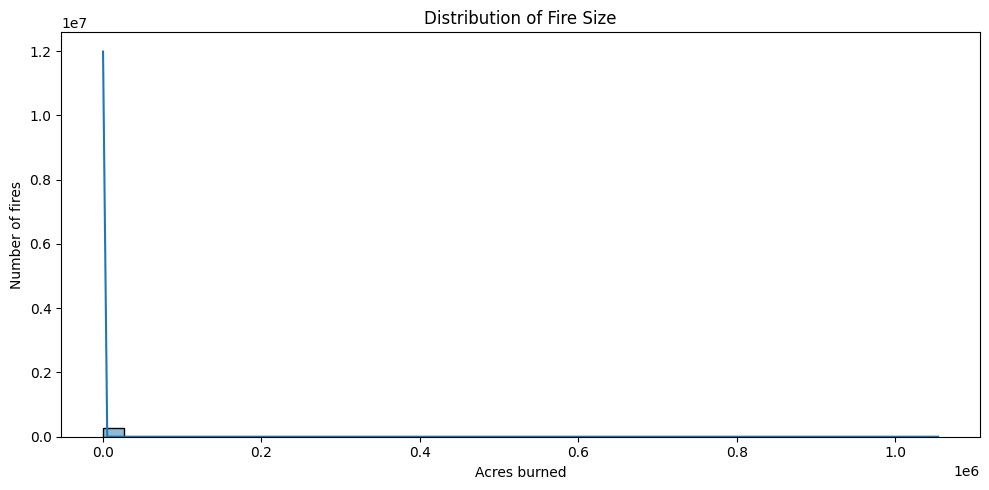

In [14]:
# Distribution of Fire Size (Raw Acres)
acres_valid = df.loc[df["acres"] >= 0, "acres"]

plt.figure(figsize=(10, 5))
sns.histplot(acres_valid, bins=40, kde=True)
plt.title("Distribution of Fire Size")
plt.xlabel("Acres burned")
plt.ylabel("Number of fires")
plt.tight_layout()
plt.show()

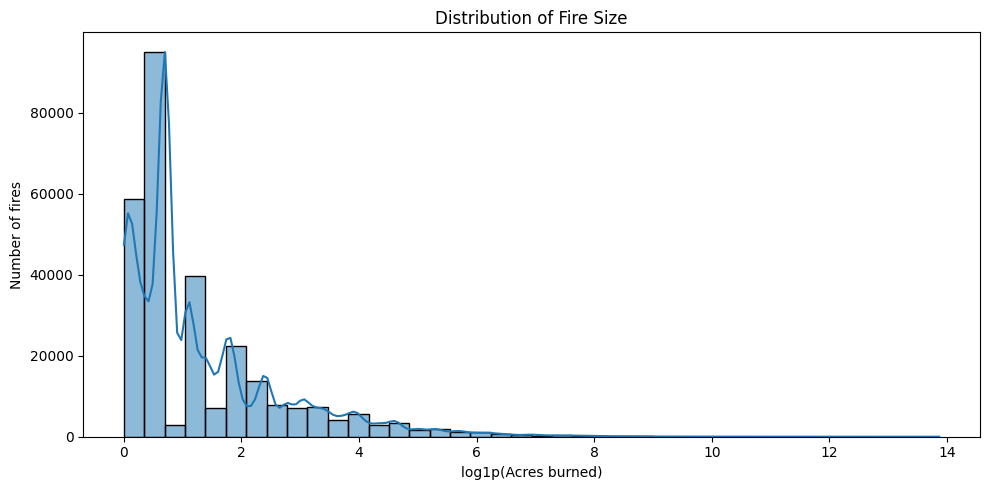

In [ ]:
# Distribution of Fire Size (Log-Transformed)

valid_acres = df.loc[df["acres"] >= 0, "acres"]

plt.figure(figsize=(10, 5))
sns.histplot(np.log1p(valid_acres), bins=40, kde=True)
plt.title("Distribution of Fire Size")
plt.xlabel("log1p(Acres burned)")
plt.ylabel("Number of fires")
plt.tight_layout()
plt.show()

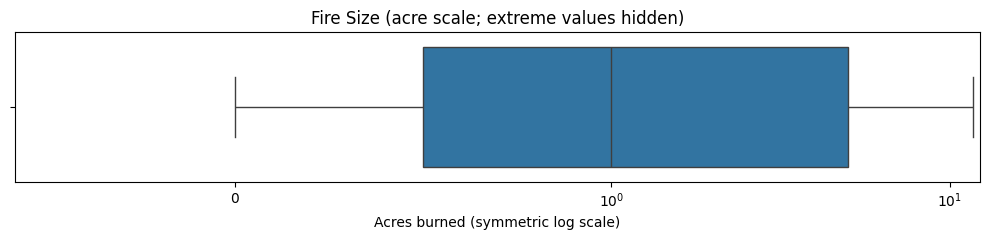

In [31]:
plt.figure(figsize=(10, 2.5))
sns.boxplot(x=valid_acres, showfliers=False)
plt.xscale("symlog", linthresh=1)
plt.title("Fire Size (acre scale; extreme values hidden)")
plt.xlabel("Acres burned (symmetric log scale)")
plt.tight_layout()
plt.show()

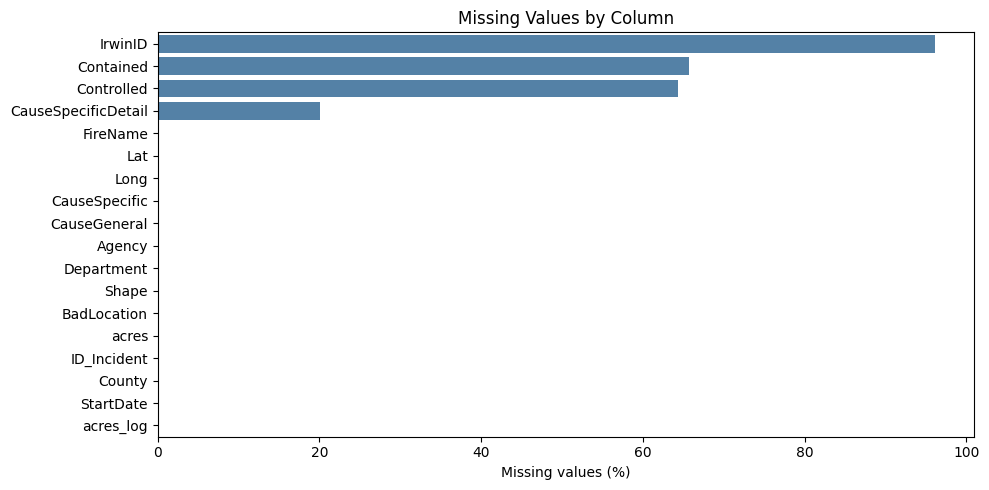

In [20]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=missing_pct.values, y=missing_pct.index, color="steelblue")
plt.title("Missing Values by Column")
plt.xlabel("Missing values (%)")
plt.ylabel("")
plt.tight_layout()
plt.show()

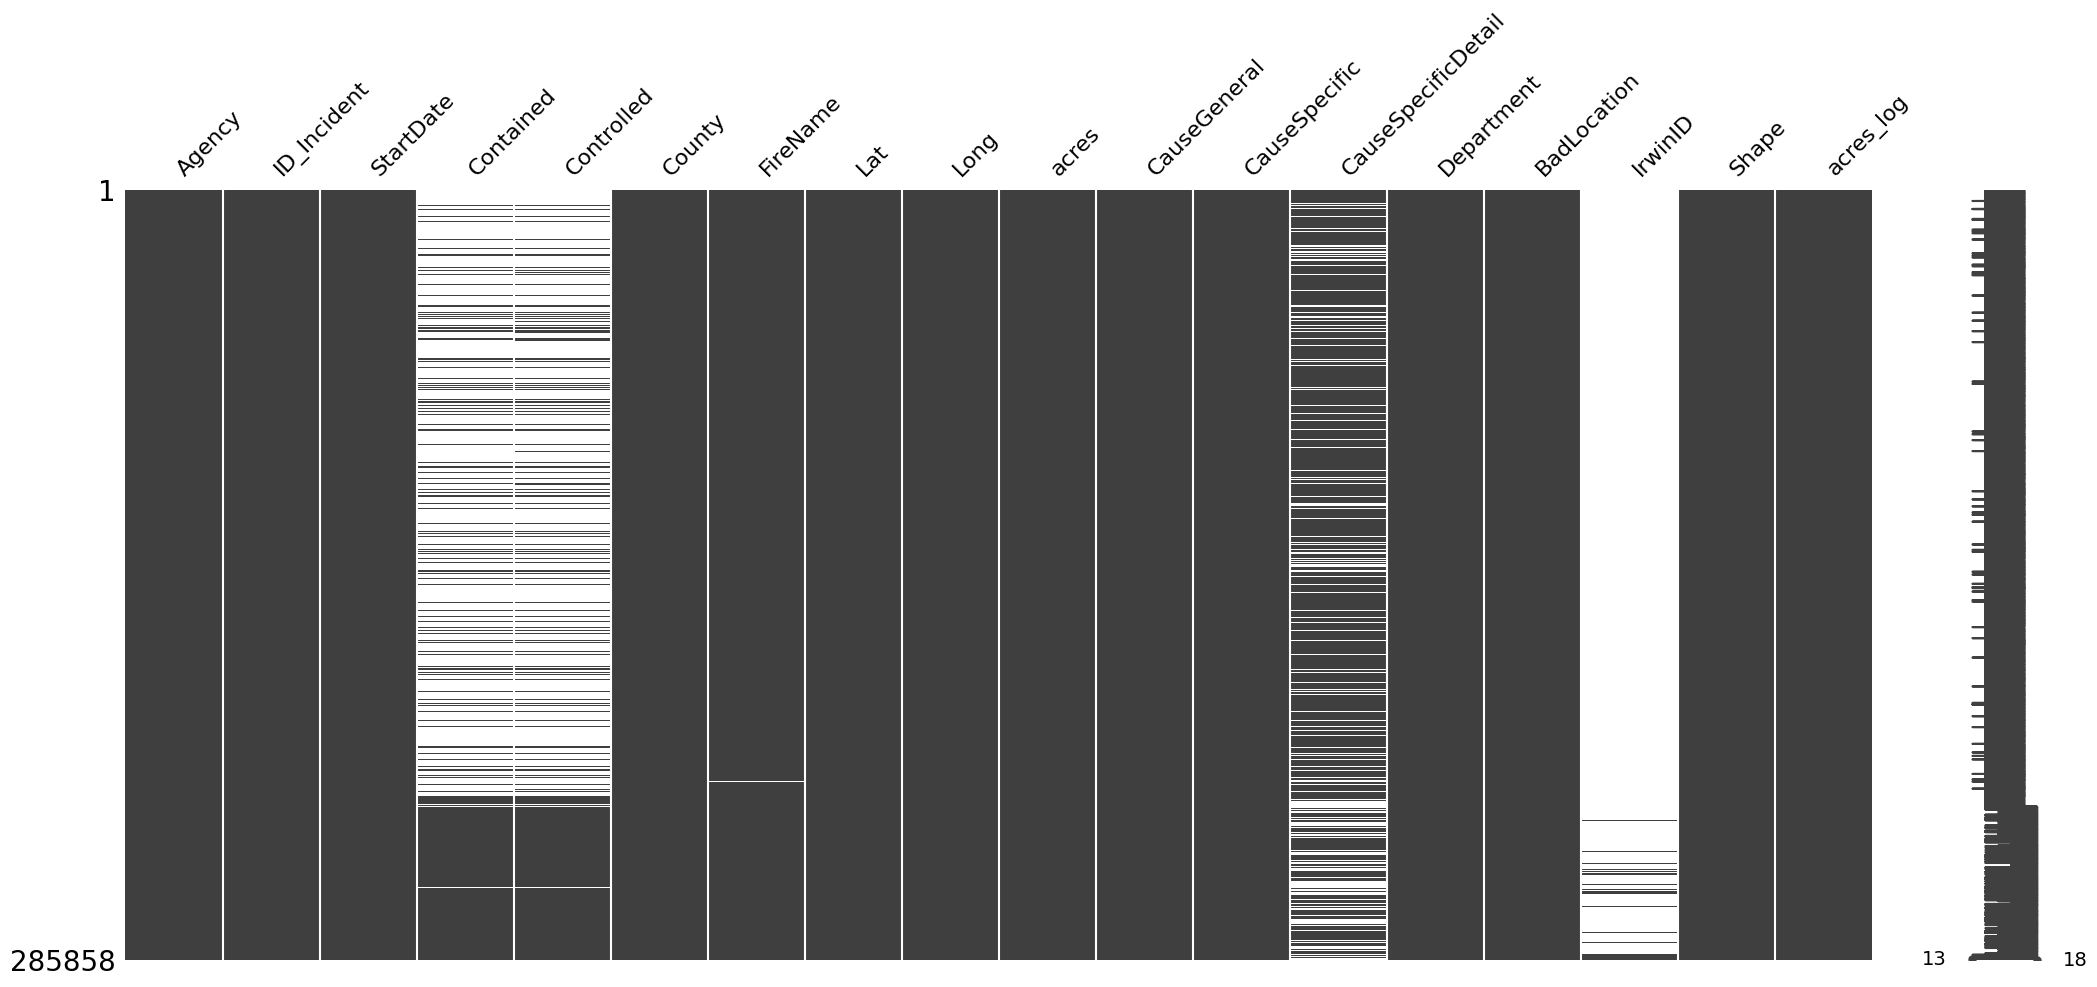

In [22]:
msno.matrix(df)
plt.show()



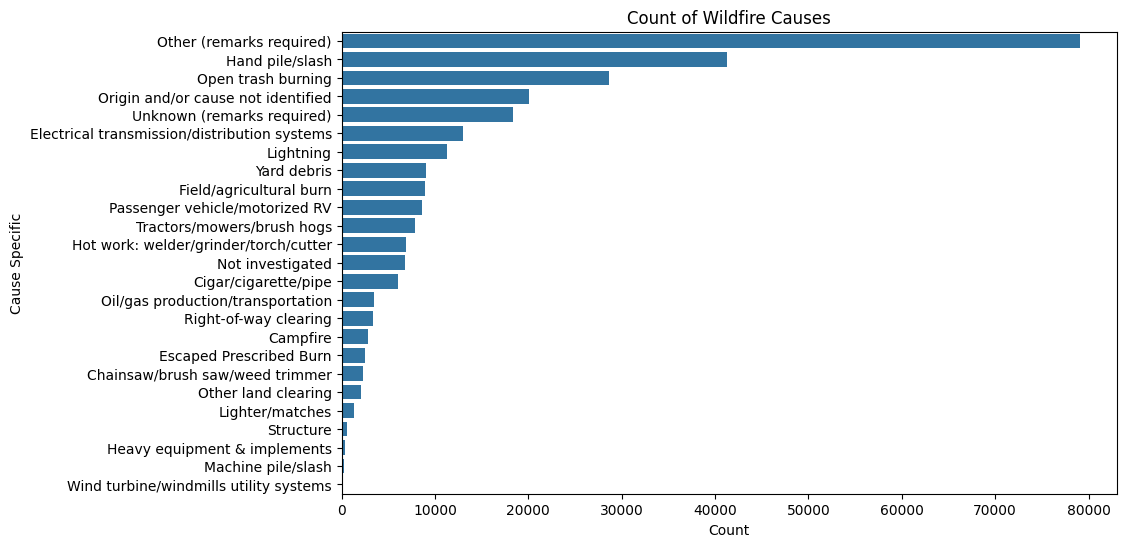

In [12]:
plt.figure(figsize=(10, 6))

sns.countplot(y='CauseSpecific', data=df, order=df['CauseSpecific'].value_counts().iloc[:25].index)
plt.title('Count of Wildfire Causes')
plt.xlabel('Count')
plt.ylabel('Cause Specific')
plt.show()

/var/folders/8z/9f9b14l53y99c8m3pl4l8krc0000gn/T/ipykernel_51612/3266914759.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["StartDate"] = pd.to_datetime(df["StartDate"], errors="coerce")


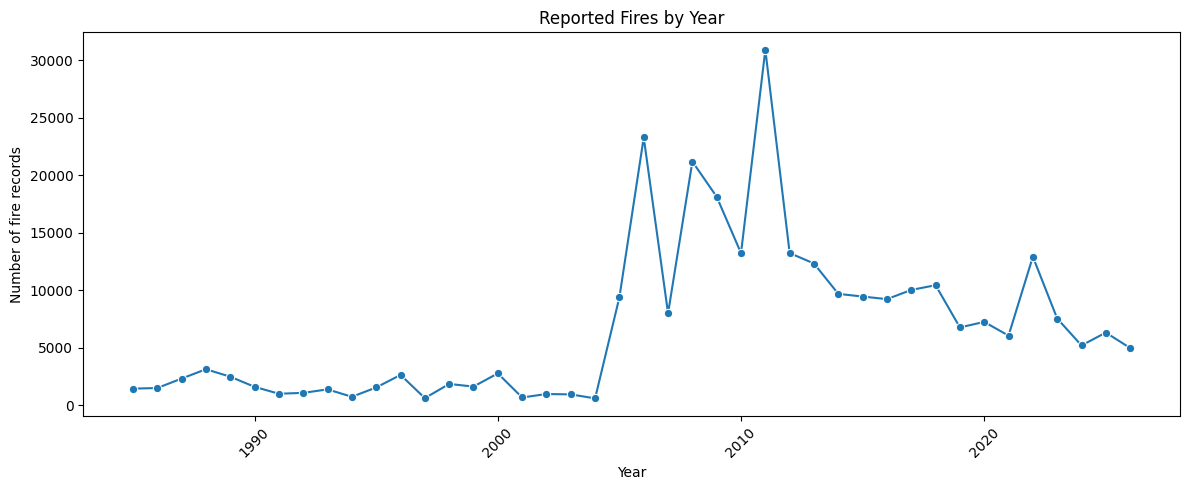

In [13]:
# Convert StartDate to datetime; invalid values become NaT
df["StartDate"] = pd.to_datetime(df["StartDate"], errors="coerce")

# Count records per year
fires_by_year = (
    df.dropna(subset=["StartDate"])
      .groupby(df["StartDate"].dt.year)
      .size()
      .rename("fire_count")
)

plt.figure(figsize=(12, 5))
sns.lineplot(x=fires_by_year.index, y=fires_by_year.values, marker="o")
plt.title("Reported Fires by Year")
plt.xlabel("Year")
plt.ylabel("Number of fire records")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

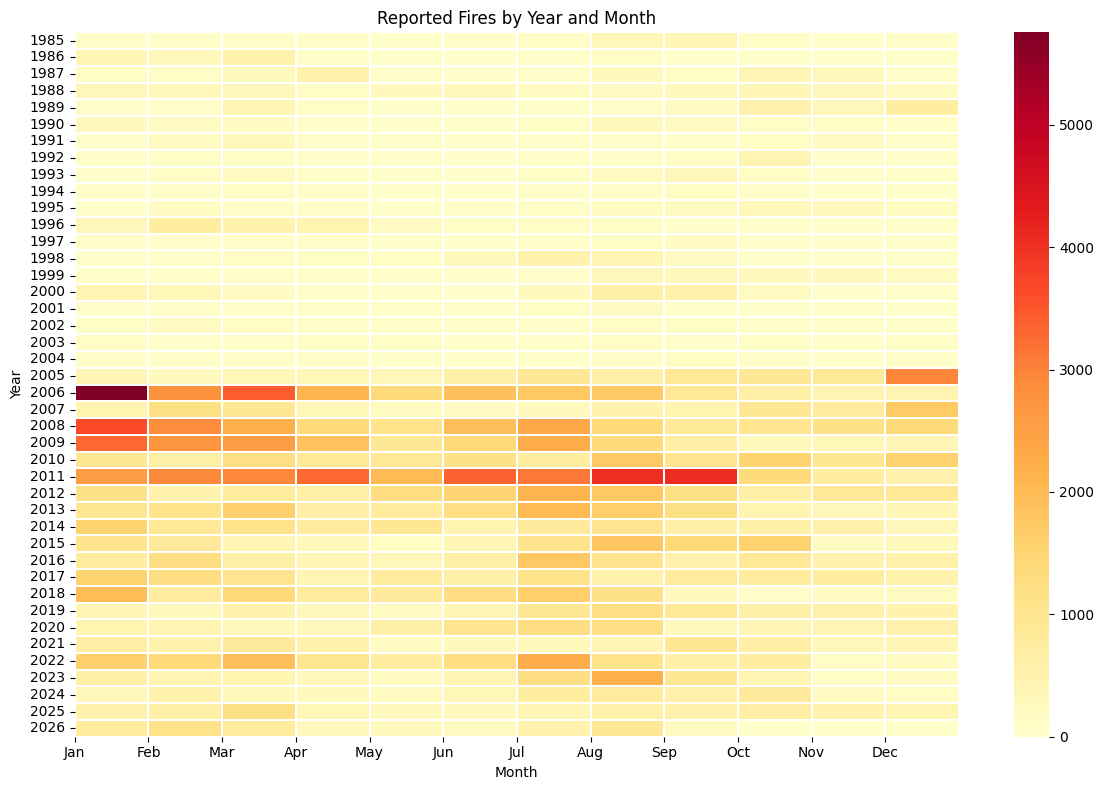

In [14]:
dated_fires = df.dropna(subset=["StartDate"]).copy()
dated_fires["year"] = dated_fires["StartDate"].dt.year
dated_fires["month"] = dated_fires["StartDate"].dt.month

fires_by_month_year = dated_fires.pivot_table(
    index="year",
    columns="month",
    values="ID_Incident",
    aggfunc="count",
    fill_value=0
)

# Ensure all months appear, even if a month has no records
fires_by_month_year = fires_by_month_year.reindex(columns=range(1, 13), fill_value=0)

plt.figure(figsize=(12, 8))
sns.heatmap(fires_by_month_year, cmap="YlOrRd", linewidths=0.2)
plt.title("Reported Fires by Year and Month")
plt.xlabel("Month")
plt.ylabel("Year")
plt.xticks(
    ticks=range(12),
    labels=["Jan", "Feb", "Mar", "Apr", "May", "Jun",
            "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"],
    rotation=0
)
plt.tight_layout()
plt.show()

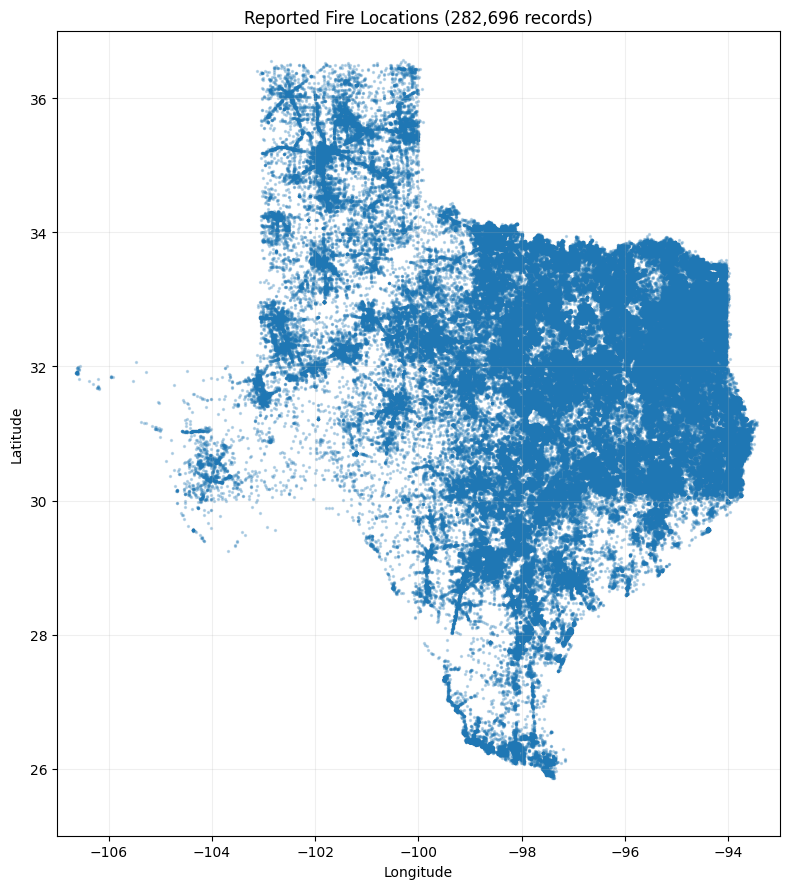

In [17]:
# Keep valid coordinates and exclude records flagged as bad
geo = df[
    df["Lat"].between(25, 37) &
    df["Long"].between(-107, -93) &
    (df["BadLocation"] == 0)
].copy()

plt.figure(figsize=(8, 9))
plt.scatter(
    geo["Long"],
    geo["Lat"],
    s=2,
    alpha=0.25
)
plt.title(f"Reported Fire Locations ({len(geo):,} records)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.xlim(-107, -93)
plt.ylim(25, 37)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

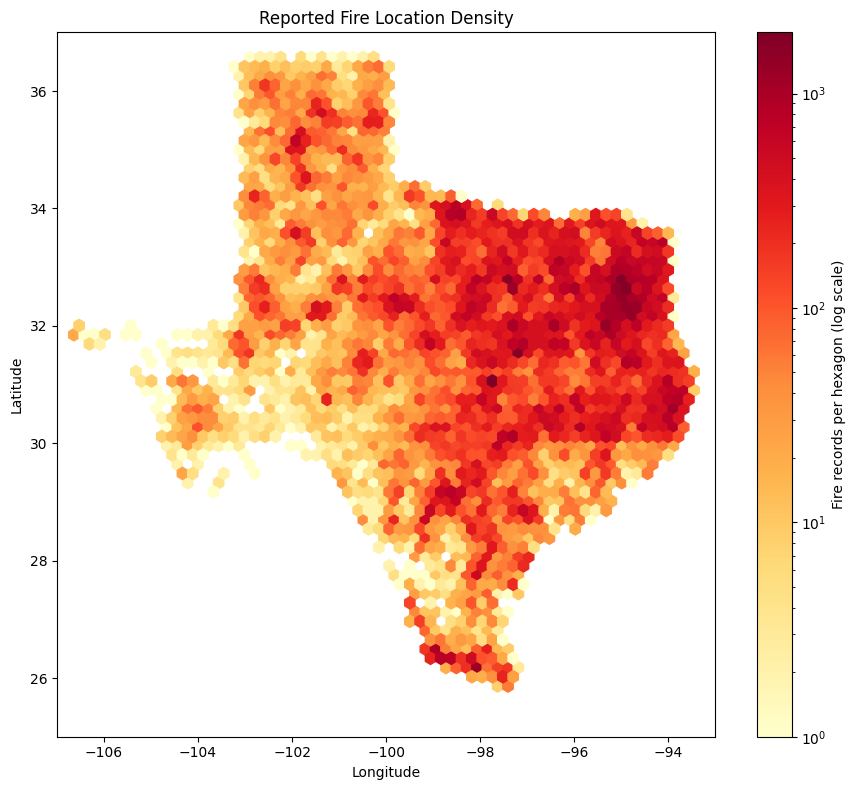

In [16]:
# Keep plausible Texas coordinates and exclude records flagged as bad
geo = df[
    df["Lat"].between(25, 37) &
    df["Long"].between(-107, -93) &
    (df["BadLocation"] == 0)
].dropna(subset=["Lat", "Long"])

plt.figure(figsize=(9, 8))

hb = plt.hexbin(
    geo["Long"],
    geo["Lat"],
    gridsize=60,       # Increase for smaller hexagons; decrease for larger ones
    mincnt=1,          # Hide empty hexagons
    bins="log",        # Makes areas with many records easier to distinguish
    cmap="YlOrRd"
)

plt.colorbar(hb, label="Fire records per hexagon (log scale)")
plt.title("Reported Fire Location Density")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.xlim(-107, -93)
plt.ylim(25, 37)
plt.tight_layout()
plt.show()

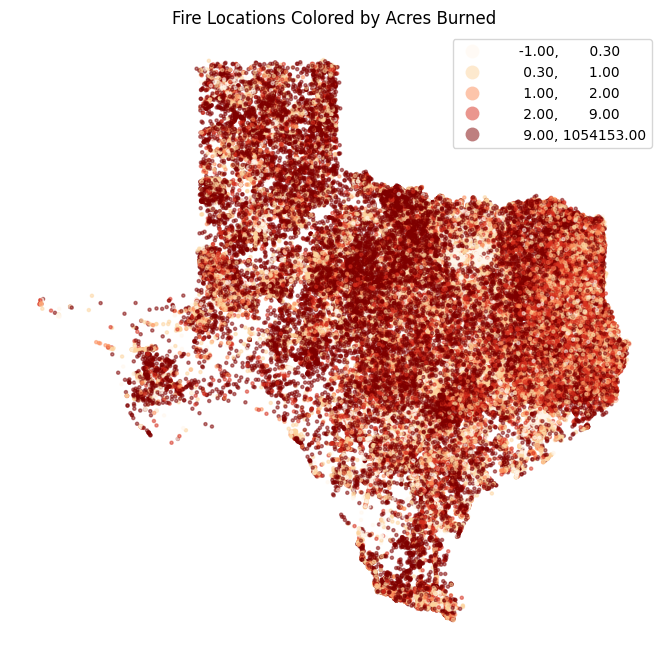

In [44]:
fires_gdf.plot(
    column="acres",
    cmap="OrRd",
    legend=True,
    markersize=5,
    alpha=0.5,
    figsize=(9, 8),
    scheme="quantiles"
)
plt.title("Fire Locations Colored by Acres Burned")
plt.axis("off")
plt.show()

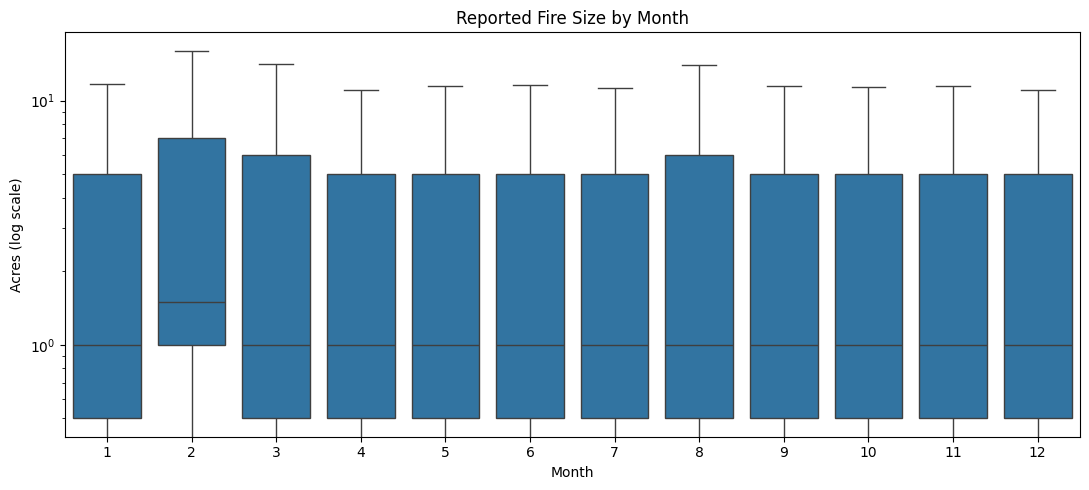

In [24]:
df["month"] = df["StartDate"].dt.month

plt.figure(figsize=(11, 5))
sns.boxplot(data=df, x="month", y="acres", showfliers=False)
plt.yscale("log")
plt.title("Reported Fire Size by Month")
plt.xlabel("Month")
plt.ylabel("Acres (log scale)")
plt.tight_layout()
plt.show()

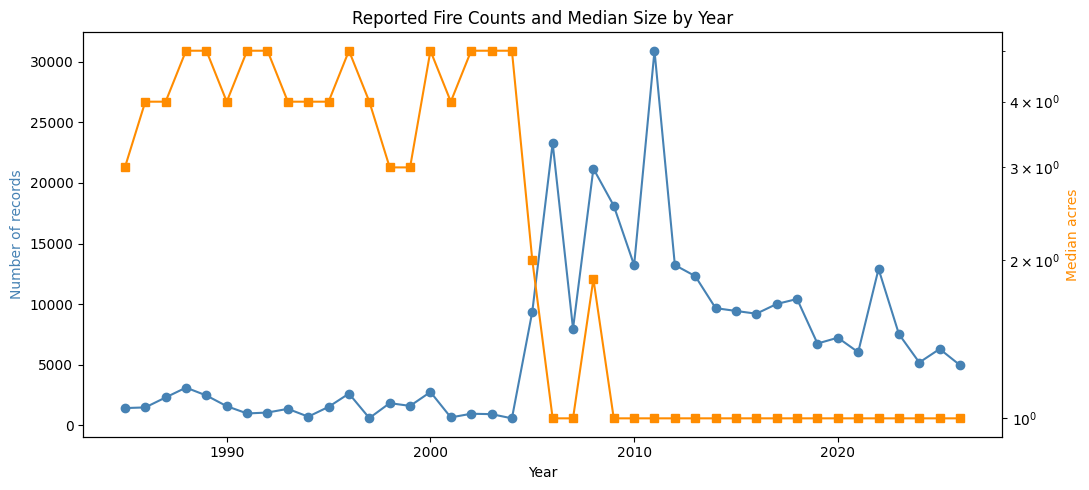

In [25]:
fig, ax1 = plt.subplots(figsize=(11, 5))

ax1.plot(yearly["year"], yearly["fire_count"], marker="o", color="steelblue")
ax1.set_xlabel("Year")
ax1.set_ylabel("Number of records", color="steelblue")

ax2 = ax1.twinx()
ax2.plot(yearly["year"], yearly["median_acres"], marker="s", color="darkorange")
ax2.set_ylabel("Median acres", color="darkorange")
ax2.set_yscale("log")

plt.title("Reported Fire Counts and Median Size by Year")
fig.tight_layout()
plt.show()

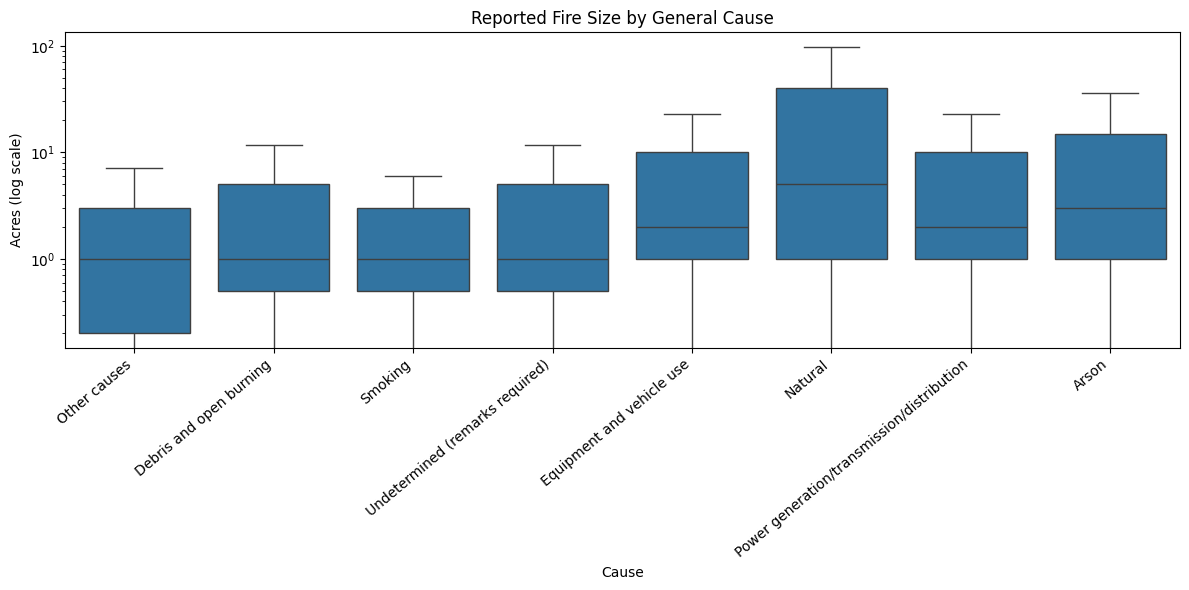

In [26]:
top_causes = df["CauseGeneral"].value_counts().head(8).index
cause_data = df[df["CauseGeneral"].isin(top_causes)].copy()

plt.figure(figsize=(12, 6))
sns.boxplot(data=cause_data, x="CauseGeneral", y="acres", showfliers=False)
plt.yscale("log")
plt.xticks(rotation=40, ha="right")
plt.title("Reported Fire Size by General Cause")
plt.xlabel("Cause")
plt.ylabel("Acres (log scale)")
plt.tight_layout()
plt.show()

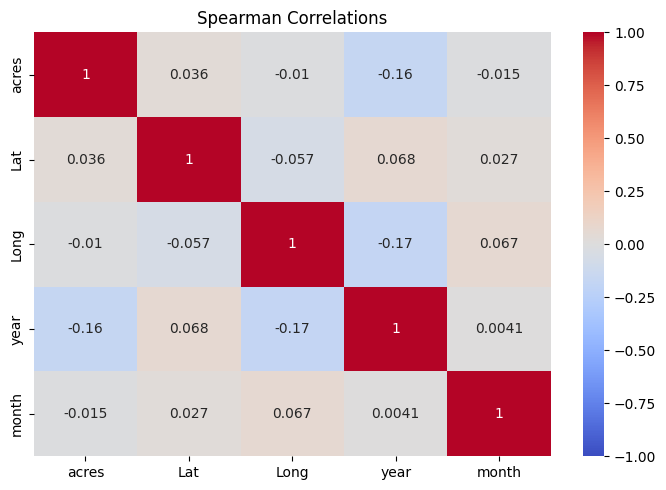

In [28]:
corr_data = dated.assign(
    year=dated["StartDate"].dt.year,
    month=dated["StartDate"].dt.month
)[["acres", "Lat", "Long", "year", "month"]]

corr = corr_data.corr(method="spearman")

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Spearman Correlations")
plt.tight_layout()
plt.show()

## Testing GeoPandas

In [ ]:
import geopandas as gpd

#Filters your records to usuable locations by turning them into geographic points

# Keep valid coordinates and exclude records flagged as bad
geo_df = df[
    df["Lat"].between(25, 37) &
    df["Long"].between(-107, -93) &
    (df["BadLocation"] == 0)
].dropna(subset=["Lat", "Long"]).copy()

fires_gdf = gpd.GeoDataFrame(
    geo_df,
    geometry=gpd.points_from_xy(geo_df["Long"], geo_df["Lat"]),
    crs="EPSG:4326"  # Longitude/latitude coordinates
)

fires_gdf.head()

,Agency,ID_Incident,StartDate,Contained,Controlled,County,FireName,Lat,Long,acres,...,CauseSpecific,CauseSpecificDetail,Department,BadLocation,IrwinID,Shape,acres_log,year,month,geometry
0,FD,AEA0A967-E4C9-45C3-BD5F-0000D3C0A9DD,2011-07-17 00:00:00,NaN,NaN,Wichita,Rekindle Krohn Rd,34.091480,-98.898642,0.0,...,Other (remarks required),Unknown (remarks required),Electra VFD,0,NaN,0xE6100000010CF833BC5983B958C0CD1C37A1B50B4140,0.000000,2011,7,POINT (-98.89864 34.09148)
1,FD,5E7D8AA7-872F-4C28-849C-0001031ACCD5,2020-04-08 12:59:00,4/8/20 13:16,4/8/20 13:52,Aransas,190,28.057600,-97.104200,0.1,...,Hand pile/slash,Unknown (remarks required),Rockport VFD,0,NaN,0xE6100000010C910F7A36AB4658C0E63FA4DFBE0E3C40,0.095310,2020,4,POINT (-97.1042 28.0576)
2,FD,A9DBA206-FB1E-4061-9500-0001FC0A547D,2009-04-25 00:00:00,NaN,NaN,Bee,Grass Fire,28.413202,-97.723735,0.5,...,Cigar/cigarette/pipe,Unknown (remarks required),Beeville Vol. Fire Dept.,0,NaN,0xE6100000010C000B70AC516E58C07CD43EA1C7693C40,0.405465,2009,4,POINT (-97.72373 28.4132)
3,FD,E47D6494-9964-4F0A-B4F8-0002615830C7,2008-01-29 00:00:00,NaN,NaN,Bell,7000 Stillman Valley,30.934168,-97.716991,20.0,...,Hand pile/slash,Unknown (remarks required),Florence VFD,0,NaN,0xE6100000010C5002F62CE36D58C0344205A825EF3E40,3.044522,2008,1,POINT (-97.71699 30.93417)
4,FD,7CD8FF55-5E90-450B-8687-0002A206891B,2008-06-17 00:00:00,NaN,NaN,Mills,Stone Creek #3,31.557167,-98.665667,1.0,...,Other (remarks required),Unknown (remarks required),Mullin Volunteer Fire Department,0,NaN,0xE6100000010C874215489AAA58C01E1F6779A28E3F40,0.693147,2008,6,POINT (-98.66567 31.55717)


## Summarize Wildfire Data by County

In [ ]:
# Summarize wildfire data by county, including fire count, total acres burned, and median acres burned

county_summary = (
    fires_gdf.groupby("County")
    .agg(
        fire_count=("ID_Incident", "count"),
        total_acres=("acres", "sum"),
        median_acres=("acres", "median")
    )
    .reset_index()
)

county_summary.sort_values("total_acres", ascending=False).head(10)

,County,fire_count,total_acres,median_acres
116,Hutchinson,1068,2108385.82,2.00
121,Jeff Davis,435,528764.09,10.00
147,Lipscomb,266,446673.40,22.50
29,Callahan,1766,408001.00,1.00
21,Brewster,156,325513.51,10.25
181,Palo Pinto,2776,317229.49,1.00
170,Moore,286,277469.25,1.00
1,Andrews,1014,277106.45,2.00
185,Pecos,163,267847.02,5.00
89,Gray,368,262121.20,5.00


## Baseline modeling 

In [ ]:
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# Parse dates and keep rows with a valid date and nonnegative target
data = df.copy()
data["StartDate"] = pd.to_datetime(data["StartDate"], errors="coerce")
data = data.dropna(subset=["StartDate", "acres"])
data = data[data["acres"] >= 0].copy()

# Example predictors available at or near fire start
data["month"] = data["StartDate"].dt.month
features = ["Lat", "Long", "month", "County", "CauseGeneral"]
target = "acres"

# Hold out the latest 20% of records by date for testing
data = data.sort_values("StartDate")
split_at = int(len(data) * 0.8)
train = data.iloc[:split_at]
test = data.iloc[split_at:]

X_train, y_train = train[features], train[target]
X_test, y_test = test[features], test[target]

numeric_features = ["Lat", "Long", "month"]
categorical_features = ["County", "CauseGeneral"]

preprocess = ColumnTransformer([
    ("numeric", SimpleImputer(strategy="median"), numeric_features),
    ("categorical", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features)
])

models = {
    "Median baseline": DummyRegressor(strategy="median"),
    "Random forest": Pipeline([
        ("preprocess", preprocess),
        ("model", RandomForestRegressor(
            n_estimators=200,
            min_samples_leaf=5,
            random_state=42,
            n_jobs=-1
        ))
    ])
}

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    print(
        f"{name}: "
        f"MAE={mean_absolute_error(y_test, predictions):.2f} acres, "
        f"RMSE={np.sqrt(mean_squared_error(y_test, predictions)):.2f} acres, "
        f"R²={r2_score(y_test, predictions):.3f}"
    )


Median baseline: MAE=56.38 acres, RMSE=4504.81 acres, R²=-0.000


In [46]:
from sklearn.compose import TransformedTargetRegressor

log_model = TransformedTargetRegressor(
    regressor=Pipeline([
        ("preprocess", preprocess),
        ("model", RandomForestRegressor(
            n_estimators=200,
            min_samples_leaf=5,
            random_state=42,
            n_jobs=-1
        ))
    ]),
    func=np.log1p,
    inverse_func=np.expm1
)

log_model.fit(X_train, y_train)
predictions = log_model.predict(X_test)

# Acres can't be negative
predictions = np.maximum(predictions, 0)

print(f"Log-target model: "
      f"MAE={mean_absolute_error(y_test, predictions):.2f} acres, "
      f"RMSE={np.sqrt(mean_squared_error(y_test, predictions)):.2f} acres, "
      f"R²={r2_score(y_test, predictions):.3f}")

Log-target model: MAE=67.35 acres, RMSE=4504.61 acres, R²=-0.000


In [47]:
median_model = DummyRegressor(strategy="median")
median_model.fit(X_train, y_train)
median_predictions = median_model.predict(X_test)

rf_model = models["Random forest"]
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

KeyboardInterrupt: 

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, name, pred in [
    (axes[0], "Median baseline", median_predictions),
    (axes[1], "Random forest", rf_predictions)
]:
    # Clip at zero for plotting; acreage predictions should not be negative
    actual_plot = np.maximum(y_test, 0)
    pred_plot = np.maximum(pred, 0)

    ax.scatter(actual_plot, pred_plot, alpha=0.25, s=12)
    ax.set_xscale("symlog", linthresh=1)
    ax.set_yscale("symlog", linthresh=1)
    ax.set_xlabel("Actual acres")
    ax.set_ylabel("Predicted acres")
    ax.set_title(name)

plt.suptitle("Actual vs. Predicted Fire Size")
plt.tight_layout()
plt.show()

## Multiple Linear Regression Baselines

Compare a raw numeric baseline (latitude, longitude, year, month) with a cleaned model that also one-hot encodes county and general cause. Both use a chronological 80/20 split. The target is nonnegative acres. `Contained`, `Controlled`, IDs, and fire names are excluded because they are unavailable or inappropriate predictors for an early fire-size estimate.

The raw model uses complete numeric rows; the encoded model imputes missing predictor values and can use more rows. Compare row counts along with the metrics.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Prepare target, date features, and a chronological train/test split.
model_data = df.copy()
model_data["StartDate"] = pd.to_datetime(model_data["StartDate"], errors="coerce")
model_data = model_data.dropna(subset=["StartDate", "acres"]).copy()
model_data = model_data[model_data["acres"] >= 0].copy()
model_data["year"] = model_data["StartDate"].dt.year
model_data["month"] = model_data["StartDate"].dt.month
model_data["County"] = model_data["County"].fillna("Missing").astype(str)
model_data["CauseGeneral"] = model_data["CauseGeneral"].fillna("Missing").astype(str)

# Predictor sets: raw numeric features versus numeric + one-hot encoded categories.
raw_features = ["Lat", "Long", "year", "month"]
encoded_features_before_encoding = raw_features + ["County", "CauseGeneral"]
target = "acres"

# Raw model uses complete cases for its four numeric predictors.
raw_data = model_data.dropna(subset=raw_features).sort_values("StartDate").copy()
raw_split = int(len(raw_data) * 0.8)
raw_train, raw_test = raw_data.iloc[:raw_split], raw_data.iloc[raw_split:]
X_raw_train, y_raw_train = raw_train[raw_features], raw_train[target]
X_raw_test, y_raw_test = raw_test[raw_features], raw_test[target]

raw_model = Pipeline([
    ("scale", StandardScaler()),
    ("regression", LinearRegression())
])
raw_model.fit(X_raw_train, y_raw_train)
raw_predictions = np.maximum(raw_model.predict(X_raw_test), 0)

# Encoded model imputes missing numeric values and one-hot encodes categories.
encoded_data = model_data.sort_values("StartDate").copy()
encoded_split = int(len(encoded_data) * 0.8)
encoded_train, encoded_test = encoded_data.iloc[:encoded_split], encoded_data.iloc[encoded_split:]
X_enc_train = encoded_train[encoded_features_before_encoding]
y_enc_train = encoded_train[target]
X_enc_test = encoded_test[encoded_features_before_encoding]
y_enc_test = encoded_test[target]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))
])
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, raw_features),
    ("categorical", categorical_pipeline, ["County", "CauseGeneral"])
])
encoded_model = Pipeline([
    ("preprocess", preprocessor),
    ("regression", LinearRegression())
])
encoded_model.fit(X_enc_train, y_enc_train)
encoded_predictions = np.maximum(encoded_model.predict(X_enc_test), 0)

# Count actual design-matrix columns after fitting the encoder.
encoded_feature_count = len(encoded_model.named_steps["preprocess"].get_feature_names_out())

# Requested evaluation summary. Rows_used is train + test rows for that model.
baseline_results = pd.DataFrame([
    {
        "model": "Raw numeric linear regression",
        "rows_used": len(raw_data),
        "features_before_encoding": len(raw_features),
        "encoded_features": len(raw_features),
        "MAE_acres": mean_absolute_error(y_raw_test, raw_predictions),
        "RMSE_acres": np.sqrt(mean_squared_error(y_raw_test, raw_predictions)),
        "R2": r2_score(y_raw_test, raw_predictions)
    },
    {
        "model": "Imputed + one-hot linear regression",
        "rows_used": len(encoded_data),
        "features_before_encoding": len(encoded_features_before_encoding),
        "encoded_features": encoded_feature_count,
        "MAE_acres": mean_absolute_error(y_enc_test, encoded_predictions),
        "RMSE_acres": np.sqrt(mean_squared_error(y_enc_test, encoded_predictions)),
        "R2": r2_score(y_enc_test, encoded_predictions)
    }
])
baseline_results.round(3)

### Actual vs. Predicted Acres

The dashed line marks perfect predictions. A symmetric log axis keeps zero and smaller fires visible while showing the long acreage tail.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_specs = [
    (axes[0], y_raw_test, raw_predictions, "Raw numeric model"),
    (axes[1], y_enc_test, encoded_predictions, "Encoded model")
]

for ax, actual, predicted, title in plot_specs:
    ax.scatter(actual, predicted, alpha=0.22, s=10)
    max_value = max(float(actual.max()), float(np.max(predicted)), 1)
    ax.plot([0, max_value], [0, max_value], "r--", linewidth=1)
    ax.set_xscale("symlog", linthresh=1)
    ax.set_yscale("symlog", linthresh=1)
    ax.set_xlabel("Actual acres")
    ax.set_ylabel("Predicted acres")
    ax.set_title(title)

plt.suptitle("Multiple Linear Regression: Actual vs. Predicted Fire Size")
plt.tight_layout()
plt.show()

### Permutation Feature Importance

Permutation importance measures how much test-set MAE worsens when one input feature is shuffled. Larger positive values mean the model relied more on that feature. For the encoded model, the importance is grouped by the original input (for example, all county indicator columns together).

In [ ]:
raw_importance = permutation_importance(
    raw_model, X_raw_test, y_raw_test,
    scoring="neg_mean_absolute_error", n_repeats=5, random_state=42, n_jobs=-1
)
encoded_importance = permutation_importance(
    encoded_model, X_enc_test, y_enc_test,
    scoring="neg_mean_absolute_error", n_repeats=5, random_state=42, n_jobs=-1
)

importance_tables = {
    "Raw numeric model": pd.Series(raw_importance.importances_mean, index=raw_features).sort_values(),
    "Encoded model": pd.Series(encoded_importance.importances_mean, index=encoded_features_before_encoding).sort_values()
}
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (title, importance) in zip(axes, importance_tables.items()):
    importance.plot(kind="barh", ax=ax, color="slateblue")
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(title)
    ax.set_xlabel("Increase in test MAE when shuffled (acres)")
    ax.set_ylabel("Input feature")
plt.suptitle("Permutation Feature Importance")
plt.tight_layout()
plt.show()